# Вейвлет-когерентность — примеры на Python


Вейвлет-когерентность (wavelet coherence) находит области в пространстве
«время–частота», где два временных ряда меняются согласованно, даже если их
мощность невелика. На графиках ниже:

* **цвет** — квадрат вейвлет-когерентности (0 — связи нет, 1 — полная),
* **стрелки** — фазовое соотношение между сигналами
  (например, стрелки вправо — в фазе, вниз — второй сигнал отстаёт на 90°),
* **чёрная линия** — *конус влияния* (cone of influence, COI); значения выше
  него подвержены краевым эффектам и требуют осторожной интерпретации.

Цель — научиться читать график когерентности на простых, хорошо понятных
сигналах.

## Подготовка

Мы используем небольшую вспомогательную функцию `plot_wct`. Для каждой пары
сигналов она строит три панели друг под другом с общей осью времени и
логарифмической осью периода:

1. **вейвлет-мощность** первого сигнала,
2. **вейвлет-мощность** второго сигнала,
3. их **вейвлет-когерентность** со стрелками фазы и конусом влияния.

Спектры мощности (цвет — `log10` мощности) показывают, *где* у каждого
сигнала сосредоточена энергия. Когерентность имеет смысл только на тех
масштабах, где **обе** панели мощности окрашены, — см. замечание о
маскировании ниже.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pycwt
from pycwt import Morlet

plt.rcParams["figure.figsize"] = (10, 11)
plt.rcParams["figure.dpi"] = 110


def plot_wct(t, y1, y2, title="", dt=None, n_arrows=(18, 40),
             power_frac=0.05, label1="сигнал 1", label2="сигнал 2"):
    # Строит вейвлет-когерентность и вейвлет-мощность обоих сигналов.
    #
    # Три панели друг под другом с общей осью времени и лог. осью периода:
    #   1. вейвлет-мощность y1
    #   2. вейвлет-мощность y2
    #   3. вейвлет-когерентность
    #
    # t : массив моментов времени
    # y1, y2 : два входных сигнала
    # title : заголовок панели когерентности
    # dt : шаг дискретизации (по умолчанию t[1] - t[0])
    # power_frac : закрашивать серым масштабы, где мощность сигнала ниже
    #              этой доли от его максимальной мощности.
    if dt is None:
        dt = t[1] - t[0]

    # Одинаковые параметры вейвлета для когерентности и спектров мощности.
    wavelet = Morlet()
    s0 = 2 * dt / wavelet.flambda()
    dj = 1 / 12
    J = int(np.round(np.log2(y1.size * dt / s0) / dj))

    # Вейвлет-когерентность. sig=False: тест значимости рассчитан на случайный
    # сигнал и не имеет смысла для чистых синусоид.
    WCT, aWCT, coi, freq, _ = pycwt.wct(y1, y2, dt, dj=dj, s0=s0, J=J,
                                        wavelet=wavelet, sig=False)

    # Вейвлет-мощность двух сигналов.
    y1n = (y1 - y1.mean()) / y1.std()
    y2n = (y2 - y2.mean()) / y2.std()
    W1 = pycwt.cwt(y1n, dt, dj=dj, s0=s0, J=J, wavelet=wavelet)[0]
    W2 = pycwt.cwt(y2n, dt, dj=dj, s0=s0, J=J, wavelet=wavelet)[0]
    p1 = np.abs(W1) ** 2
    p2 = np.abs(W2) ** 2

    periods = 1.0 / freq                       # эквивалентные фурье-периоды
    T, P = np.meshgrid(t, periods)             # для стрелок фазы

    # Закрашиваем серым масштабы с пренебрежимо малой мощностью сигнала.
    floor1 = power_frac * p1.max()
    floor2 = power_frac * p2.max()
    log1 = np.ma.array(np.log10(np.maximum(p1, floor1)), mask=p1 < floor1)
    log2 = np.ma.array(np.log10(np.maximum(p2, floor2)), mask=p2 < floor2)

    # Когерентность достоверна только там, где у ОБОИХ сигналов есть мощность.
    mask = (p1 < floor1) | (p2 < floor2)
    WCT_masked = np.ma.array(WCT, mask=mask)

    cmap = plt.get_cmap("jet").copy()
    cmap.set_bad("lightgrey")

    fig, axs = plt.subplots(3, 1, sharex=True, figsize=(10, 11))

    # --- панели 1 и 2: вейвлет-мощность (цветовая шкала log10) ---
    for ax, logp, floor, label in ((axs[0], log1, floor1, label1),
                                   (axs[1], log2, floor2, label2)):
        vmax = np.log10(floor / power_frac)    # log10 максимальной мощности
        mesh = ax.pcolormesh(t, periods, logp, cmap=cmap,
                             vmin=vmax - 4, vmax=vmax, shading="auto")
        ax.fill_between(t, coi, periods.max(), color="black",
                        alpha=0.18, lw=0)
        ax.set_yscale("log")
        ax.set_ylabel("Период (с)")
        ax.set_title(f"Вейвлет-мощность: {label}")
        fig.colorbar(mesh, ax=ax, pad=0.01, label="log10 мощности")

    # --- панель 3: вейвлет-когерентность ---
    ax = axs[2]
    mesh = ax.pcolormesh(t, periods, WCT_masked, cmap=cmap,
                         vmin=0.0, vmax=1.0, shading="auto")
    ax.fill_between(t, coi, periods.max(), color="black", alpha=0.18, lw=0)

    # Стрелки фазы на прореженной сетке; пропускаются в замаскированных местах.
    di = max(1, WCT.shape[0] // n_arrows[0])
    dj2 = max(1, WCT.shape[1] // n_arrows[1])
    u = np.cos(aWCT[::di, ::dj2])
    v = np.sin(aWCT[::di, ::dj2])
    m = mask[::di, ::dj2]
    u = np.where(m, np.nan, u)
    v = np.where(m, np.nan, v)
    ax.quiver(T[::di, ::dj2], P[::di, ::dj2], u, v,
              color="k", pivot="mid", width=0.0035, headwidth=4)

    ax.set_yscale("log")
    ax.set_xlabel("Время (с)")
    ax.set_ylabel("Период (с)")
    ax.set_title(title if title else "Вейвлет-когерентность")
    fig.colorbar(mesh, ax=ax, pad=0.01, label="Вейвлет-когерентность")

    return axs


def plot_signals(t, y1, y2, title="", label1="сигнал 1", label2="сигнал 2"):
    # Строит два сигнала во времени на общей оси времени.
    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
    axs[0].plot(t, y1, lw=1, color="C0")
    axs[0].set_ylabel(label1)
    axs[1].plot(t, y2, lw=1, color="C1")
    axs[1].set_ylabel(label2)
    axs[1].set_xlabel("Время (с)")
    for ax in axs:
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    fig.tight_layout()
    return axs


## Различные синусоиды

Базовый случай — синусоида с периодом один. Мы строим семейство связанных
сигналов, сдвигая фазу, меняя амплитуду и добавляя шум.

In [2]:
t = np.linspace(0, 10, 1000)
dt = t[1] - t[0]

sin1 = np.sin(2 * np.pi * t)                 # базовая волна

sin2 = np.sin(2 * np.pi * t + np.pi / 2)     # сдвиг на π/2 назад
sin3 = np.sin(2 * np.pi * t - np.pi / 4)     # сдвиг на π/4 вперёд
sin4 = np.sin(2 * np.pi * t - np.pi)         # сдвиг на π вперёд
sin5 = np.sin(2 * np.pi * t + np.pi)         # сдвиг на π назад

sin6 = 5 * np.sin(2 * np.pi * t)             # амплитуда увеличена в пять раз

rng = np.random.default_rng(0)
noise = rng.random(1000)                     # rand(1,1000): равномерное [0,1)
sin7 = sin1 + noise                          # синусоида с шумом
sin8 = sin2 + noise                          # сдвинутая синусоида с шумом
sin9 = np.sin(2 * np.pi * t) + np.sin(1.5 * np.pi * t) 
sin10 = np.sin(1.5 * np.pi * t) 

Сравнение различных волн.

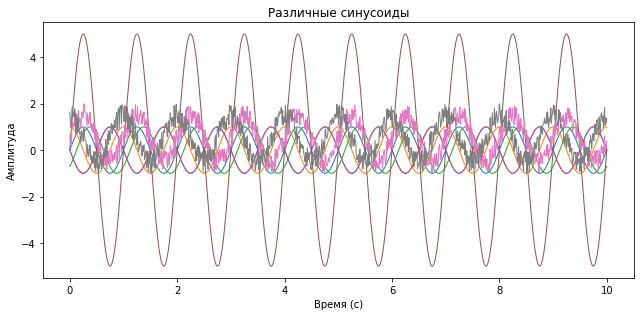

In [3]:
plt.figure(figsize=(9, 4.5))
for y in (sin1, sin2, sin3, sin4, sin5, sin6, sin7, sin8):
    plt.plot(t, y, lw=1)
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.title("Различные синусоиды")
plt.tight_layout()
plt.show()

### 1. Синусоида и сдвиг фазы $\pi/2$

Сдвиг фазы виден как стрелки, направленные вниз. Большинство областей
когерентны, особенно вдоль полосы с периодом в одну секунду.

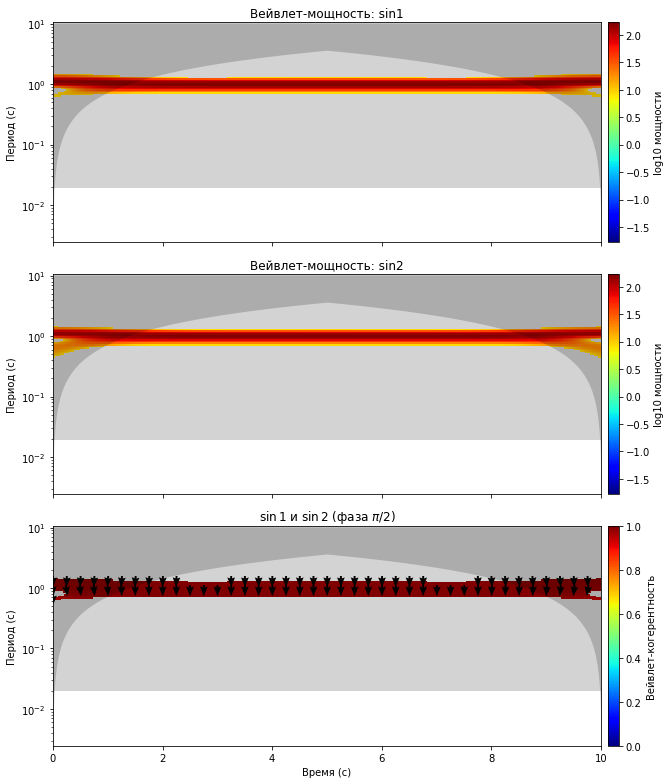

In [4]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

plot_wct(t, sin1, sin2, r"$\sin1$ и $\sin2$ (фаза $\pi/2$)", label1="sin1", label2="sin2")
plt.tight_layout()

plt.show()

### 2. Синусоида и сдвиг фазы $-\pi/4$

Стрелки направлены под углом 45°, как и ожидалось. Как и на предыдущем
рисунке, есть отдельные некогерентные области, но важная полоса хорошо видна.

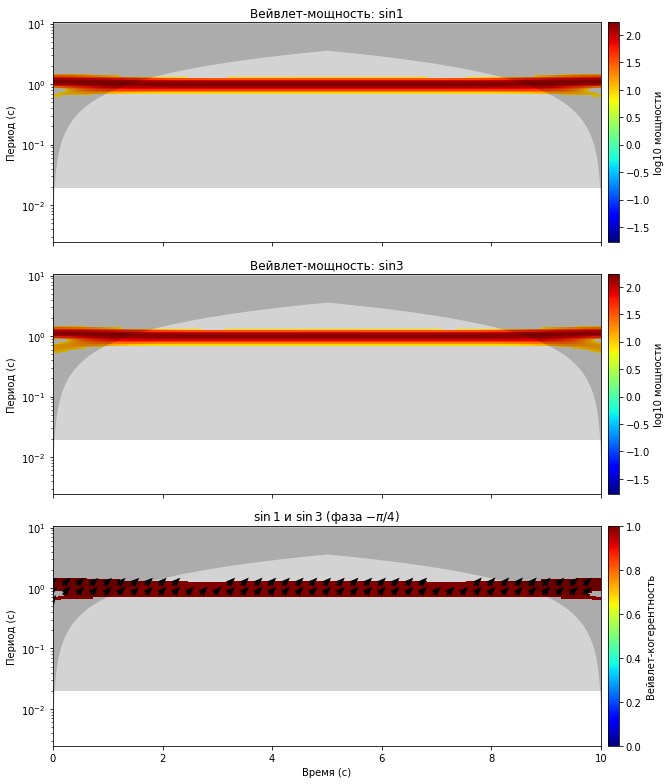

In [5]:
plot_wct(t, sin1, sin3, r"$\sin1$ и $\sin3$ (фаза $-\pi/4$)", label1="sin1", label2="sin3")
plt.tight_layout()
plt.show()

### 3. Синусоида и сдвиг фазы $\pi$

Стрелки направлены влево, и сигналы выглядят когерентными везде.

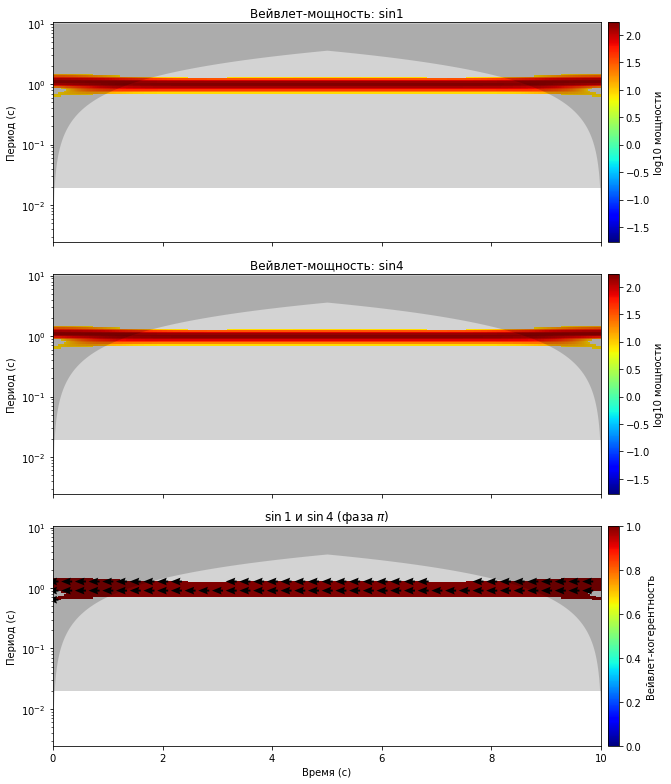

In [6]:
plot_wct(t, sin1, sin4, r"$\sin1$ и $\sin4$ (фаза $\pi$)", label1="sin1", label2="sin4")
plt.tight_layout()
plt.show()

### 4. Синусоида и сдвиг фазы $-\pi$

То же, что и на предыдущем рисунке, что показывает возможность эффекта
наложения (алиасинга) для стрелок.

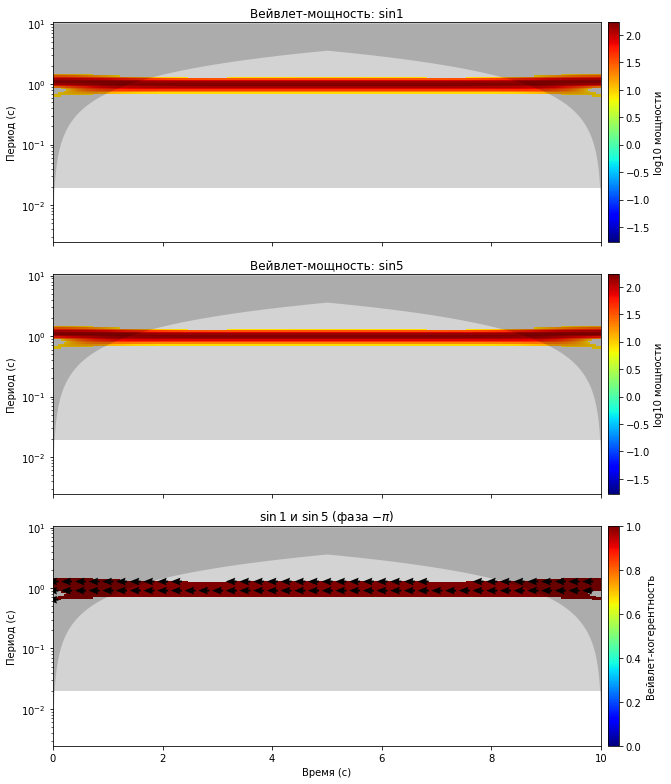

In [7]:
plot_wct(t, sin1, sin5, r"$\sin1$ и $\sin5$ (фаза $-\pi$)", label1="sin1", label2="sin5")
plt.tight_layout()
plt.show()

### 5. Синусоида с увеличенной амплитудой

Как и следовало ожидать, амплитуда не влияет на вейвлет-когерентность.

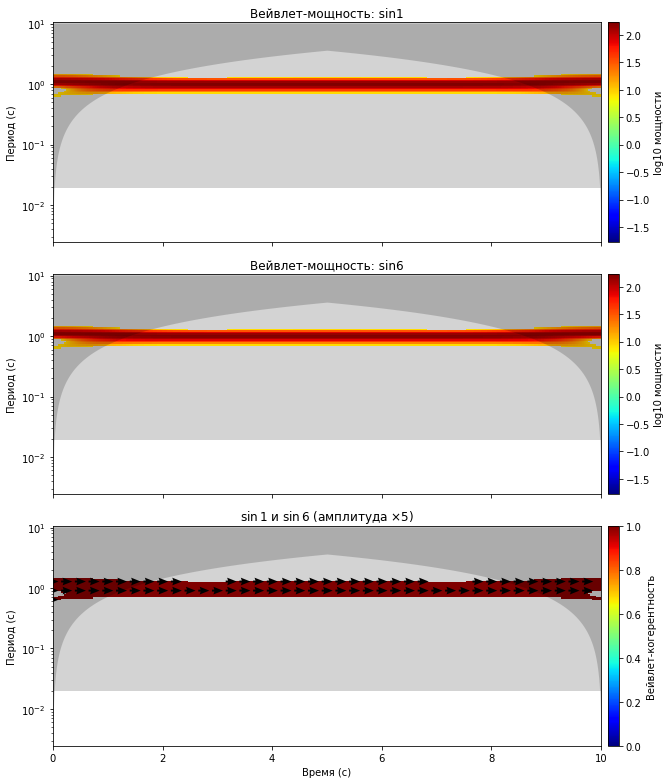

In [8]:
plot_wct(t, sin1, sin6, r"$\sin1$ и $\sin6$ (амплитуда $\times 5$)", label1="sin1", label2="sin6")
plt.tight_layout()
plt.show()

### 6. Синусоида и синусоида с шумом

Основной эффект шума — короткопериодные (высокочастотные) области перестают
быть когерентными. Это логично: шум случаен и не должен коррелировать с
гладкой кривой. Основной период (один) по-прежнему чётко виден как полоса
когерентности.

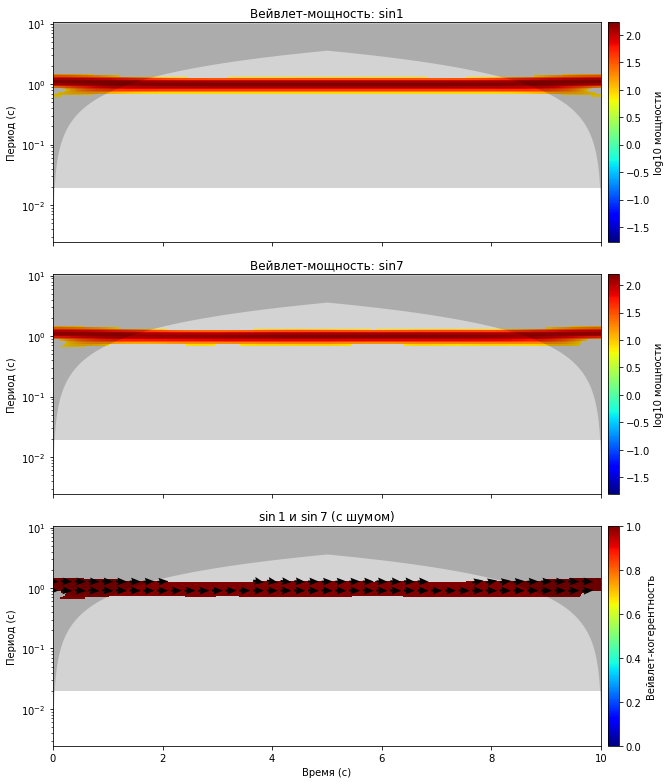

In [9]:
plot_wct(t, sin1, sin7, r"$\sin1$ и $\sin7$ (с шумом)", label1="sin1", label2="sin7")
plt.tight_layout()
plt.show()

### 7. Синусоида и сдвинутая синусоида с шумом

Как и ожидалось, мы видим сочетание предыдущих эффектов: шум убирает
когерентность на малых периодах, а когерентная полоса показывает стрелки в
сторону сдвига. Кроме того, по-видимому, теряется когерентность и на больших
периодах.

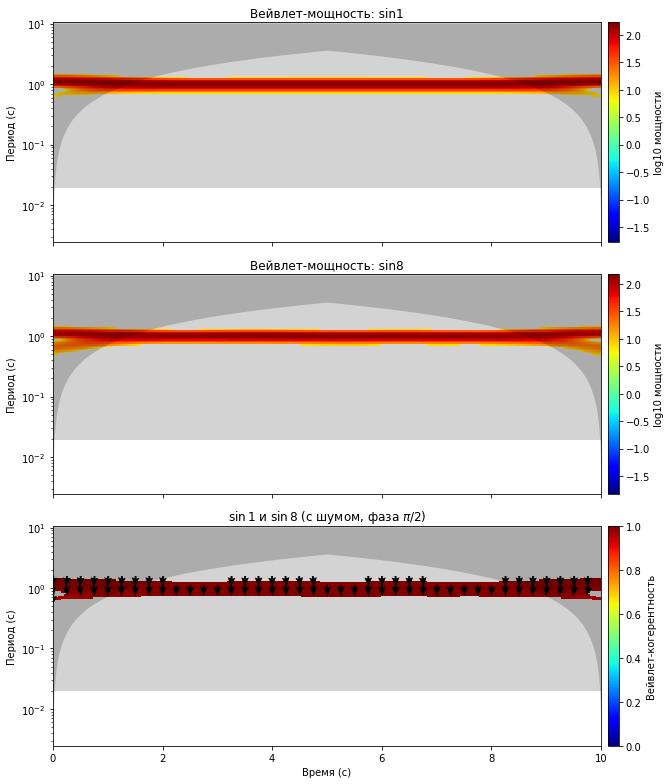

In [10]:
plot_wct(t, sin1, sin8, r"$\sin1$ и $\sin8$ (с шумом, фаза $\pi/2$)", label1="sin1", label2="sin8")
plt.tight_layout()
plt.show()

## Всегда ли сильный цвет означает общее содержание?

Не всегда. Вейвлет-когерентность — это **нормированное отношение**

$$C(a,\tau) = \frac{|S(W_1 W_2^*)|^2}{S(|W_1|^2)\,S(|W_2|^2)}$$

где $W_1(a,\tau)$ и $W_2(a,\tau)$ — непрерывные вейвлет-преобразования двух
сигналов на масштабе $a$ в момент $\tau$, $W_2^*$ — комплексно-сопряжённое к
$W_2$, а $S$ — **оператор сглаживания** (smoothing operator), применяемый и по
времени, и по масштабу (Torrence & Webster 1999; Grinsted et al. 2004). В
каждой точке $(a,\tau)$:

$$S(X)(a,\tau) = \frac{1}{N_a}\sum_{a' \in \mathcal{W}(a)}
  \underbrace{\int \frac{1}{a\sqrt{2\pi}}\,
  e^{-(\tau-\tau')^2/(2a^2)}\,X(a',\tau')\,d\tau'}_{S_\text{time}}$$

* $S_\text{time}$ — **гауссово усреднение по времени**, стандартное отклонение
  которого равно масштабу $a$ (огибающая вейвлета Морле);
* сумма — **скользящее среднее (прямоугольное окно) по соседним масштабам**
  $\mathcal{W}(a)$ шириной $2\delta j_0/dj$ (в `pycwt` $\delta j_0 = 0.6$ и
  $dj = 1/12$, то есть 14 масштабов).

Таким образом, три сглаженные величины в формуле когерентности — это:

| член | смысл |
|---|---|
| $S(W_1 W_2^*)$ | сглаженный **взаимный** спектр (комплексный; его аргумент — фазовый сдвиг) |
| $S(\lvert W_1\rvert^2)$ | сглаженный **авто**спектр (вейвлет-мощность) сигнала 1 |
| $S(\lvert W_2\rvert^2)$ | сглаженный **авто**спектр сигнала 2 |

(`pycwt` дополнительно умножает на $1/a$ перед сглаживанием, что согласуется с
нормировкой вейвлета.)

Именно это усреднение по времени и масштабу превращает шумное отношение
отдельных коэффициентов в устойчивую оценку. И как раз потому, что результат
**нормирован**, он может быть близок к 1 даже на масштабах, где у **обоих
сигналов почти нет мощности**: крошечного численного/краевого остатка
достаточно для большого отношения. Следующие два примера показывают эту
ловушку.

Чтобы её избежать, `plot_wct` теперь закрашивает серым (маскирует) все
масштабы, где вейвлет-мощность хотя бы одного сигнала ниже 5% его
максимальной мощности. **Смысл несёт только окрашенная, незамаскированная
область;** серый означает «нет информации», а не «нулевая когерентность».

Это можно проверить прямо по двум панелям мощности вверху каждого рисунка:
панель когерентности окрашена только там, где окрашены **обе** панели
мощности.

### sin9 = sin1 + тон 0.75 Гц

`sin9 = sin(2πt) + sin(1.5πt)` содержит составляющую 1 Гц, общую с `sin1`,
поэтому после маскирования остаётся настоящая когерентная полоса на периоде
1 с. Составляющая 0.75 Гц (период ≈ 1.33 с) с `sin1` *не* общая и правильно
не отмечается.

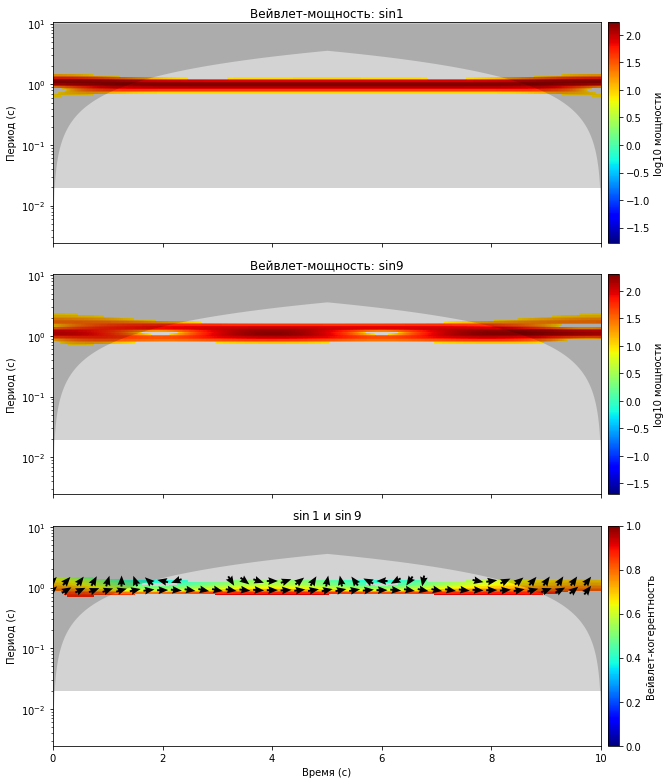

In [11]:
plot_wct(t, sin1, sin9, r"$\sin1$ и $\sin9$", label1="sin1", label2="sin9")
plt.tight_layout()
plt.show()

### sin10 = только тон 0.75 Гц

`sin10 = sin(1.5πt)` не имеет общих частот с `sin1` (1 Гц). После маскирования
областей малой мощности когерентность практически не сохраняется — широкий
красный цвет, который появлялся без маскирования, был артефактом нормировки,
а не настоящей когерентностью.

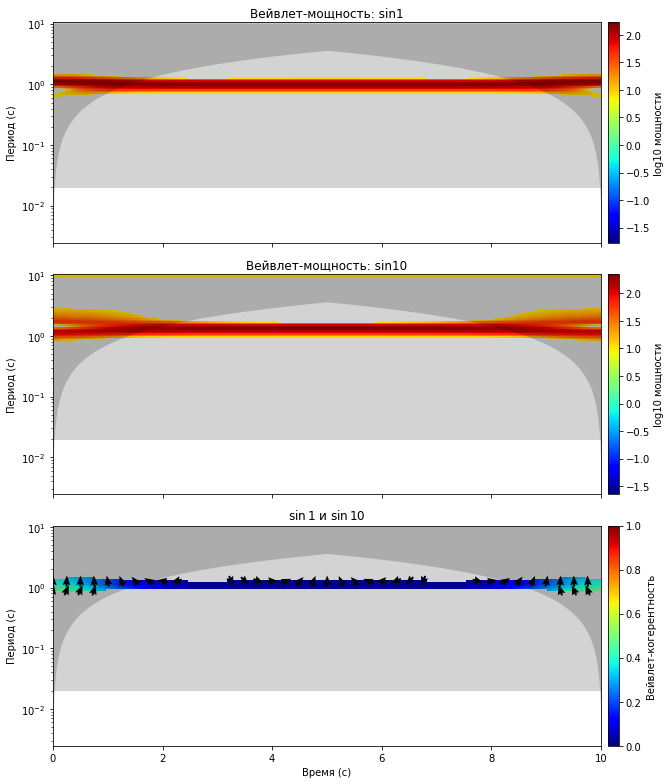

In [12]:
plot_wct(t, sin1, sin10, r"$\sin1$ и $\sin10$", label1="sin1", label2="sin10")
plt.tight_layout()
plt.show()

## Нестационарные сигналы

До сих пор всё было **стационарным**: частота и соотношение между двумя
сигналами не менялись на протяжении всей записи. Реальные измерения обычно
устроены иначе — сигнал может менять частоту, включаться и выключаться или
менять фазу в середине записи.

Именно для этого и нужен вейвлет-анализ. Поскольку каждая точка карты
когерентности локализована и по времени, и по периоду, зависимость, которая
выполняется лишь для части записи, проявляется как локализованное пятно, а не
усредняется. 

### 1. Смена режима

Оба сигнала на половине записи переключаются с 3 Гц на 1 Гц, сохраняя
постоянный фазовый сдвиг внутри каждого режима. На панели когерентности это
выглядит как **два отдельных блока** — один около периода 0.33 с в первой
половине и один около 1 с во второй половине, — а стрелки показывают фазовый
сдвиг каждого режима. Обратите внимание, как панели мощности меняют полосу
при t = 5 с.

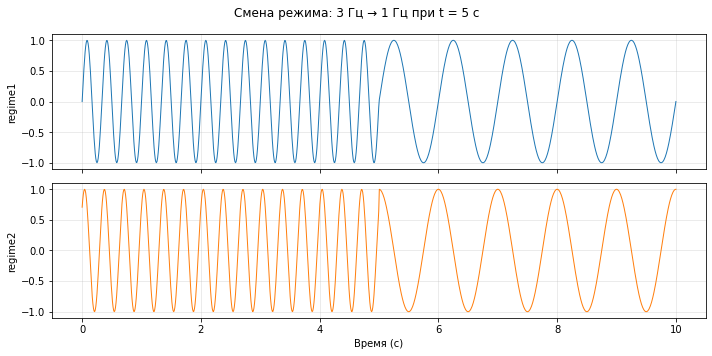

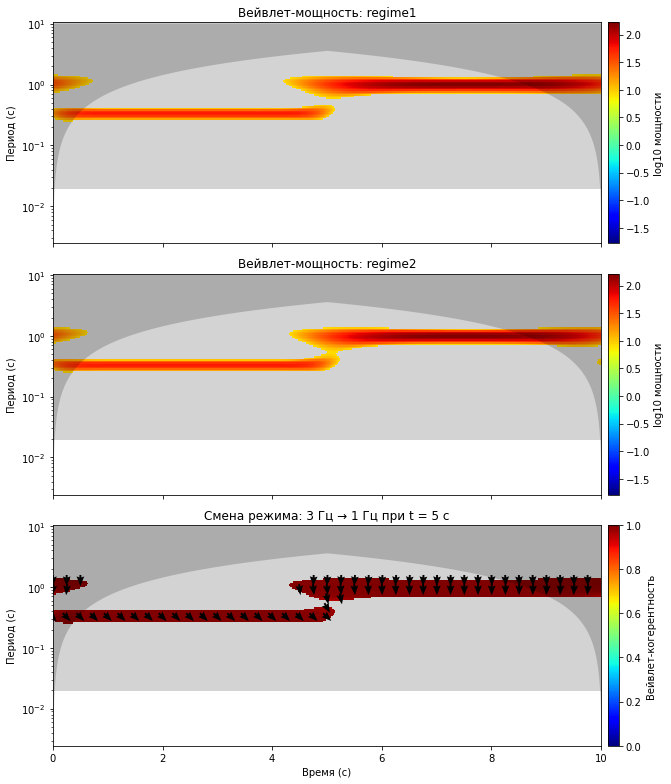

In [13]:
regime1 = np.where(t < 5, np.sin(2 * np.pi * 3 * t), np.sin(2 * np.pi * t))
regime2 = np.where(t < 5, np.sin(2 * np.pi * 3 * t + np.pi / 4),
                          np.sin(2 * np.pi * t + np.pi / 2))

plot_signals(t, regime1, regime2, "Смена режима: 3 Гц → 1 Гц при t = 5 с",
             label1="regime1", label2="regime2")

plot_wct(t, regime1, regime2,
         "Смена режима: 3 Гц → 1 Гц при t = 5 с",
         label1="regime1", label2="regime2")
plt.tight_layout()
plt.show()

### 2. Чирп, встречающий фиксированный тон

Второй сигнал — **линейный чирп**, частота которого меняется от 0.5 Гц до
2 Гц, тогда как первый остаётся на 1 Гц. Они связаны только в тот момент,
когда чирп проходит через 1 Гц (около t = 3.3 с). На панели когерентности это
**короткоживущий гребень**, а не полная полоса: вейвлет-когерентность
отслеживает нестационарную частоту, чего не может глобальная
фурье-когерентность.

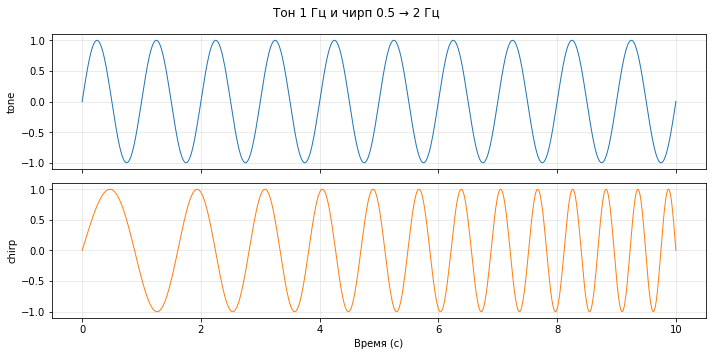

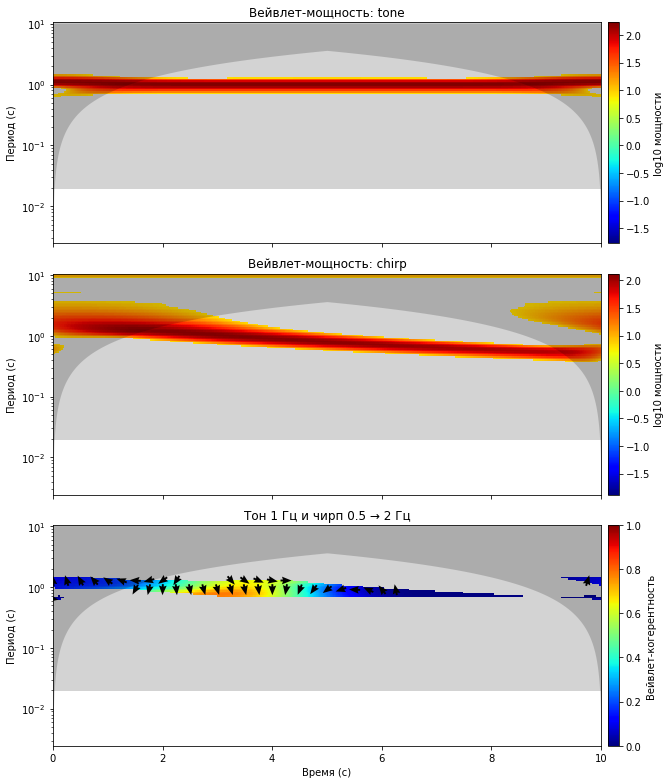

In [14]:
tone = np.sin(2 * np.pi * t)
chirp = np.sin(2 * np.pi * (0.5 * t + (2.0 - 0.5) / (2 * 10) * t**2))

plot_signals(t, tone, chirp, "Тон 1 Гц и чирп 0.5 → 2 Гц",
             label1="tone", label2="chirp")

plot_wct(t, tone, chirp, "Тон 1 Гц и чирп 0.5 → 2 Гц",
         label1="tone", label2="chirp")
plt.tight_layout()
plt.show()

### 3. Скачок фазы

Сигналы синфазны до t = 5 с, после чего второй задерживается на π/2.
Когерентная полоса присутствует всё время, но **стрелки поворачиваются** на
середине: направлены вправо (в фазе) до t = 5 с и вниз (отставание 90°) после.
Это версия примеров с постоянным сдвигом из начала ноутбука, но с разрешением
по времени.

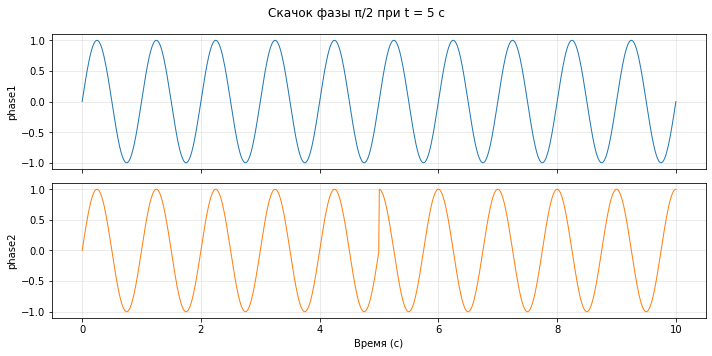

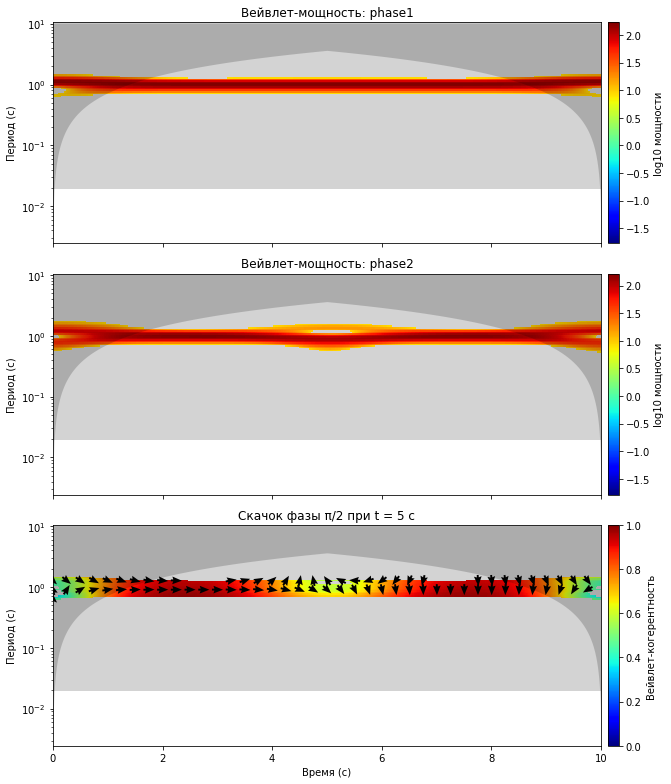

In [15]:
phase1 = np.sin(2 * np.pi * t)
phase2 = np.where(t < 5, np.sin(2 * np.pi * t), np.sin(2 * np.pi * t + np.pi / 2))

plot_signals(t, phase1, phase2, "Скачок фазы π/2 при t = 5 с",
             label1="phase1", label2="phase2")

plot_wct(t, phase1, phase2, "Скачок фазы π/2 при t = 5 с",
         label1="phase1", label2="phase2")
plt.tight_layout()
plt.show()

### 4. Локализованный во времени всплеск

Второй сигнал — синусоида 1 Гц, умноженная на гауссову огибающую с центром в
t = 5 с, поэтому заметная амплитуда у неё есть лишь несколько секунд. И
панель мощности, и панель когерентности «вспыхивают» **только во время
всплеска** и замаскированы в остальное время — прямое свидетельство того, что
метод локализует когерентность во времени.

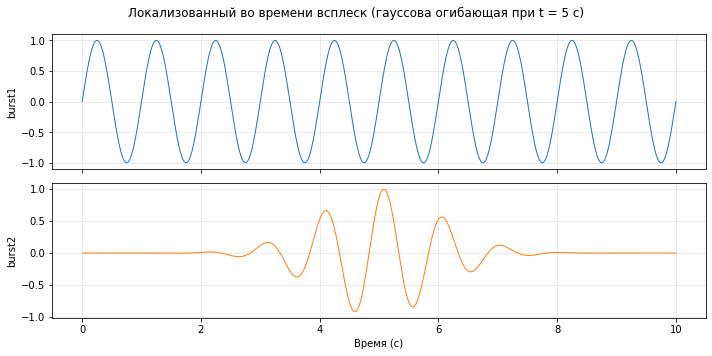

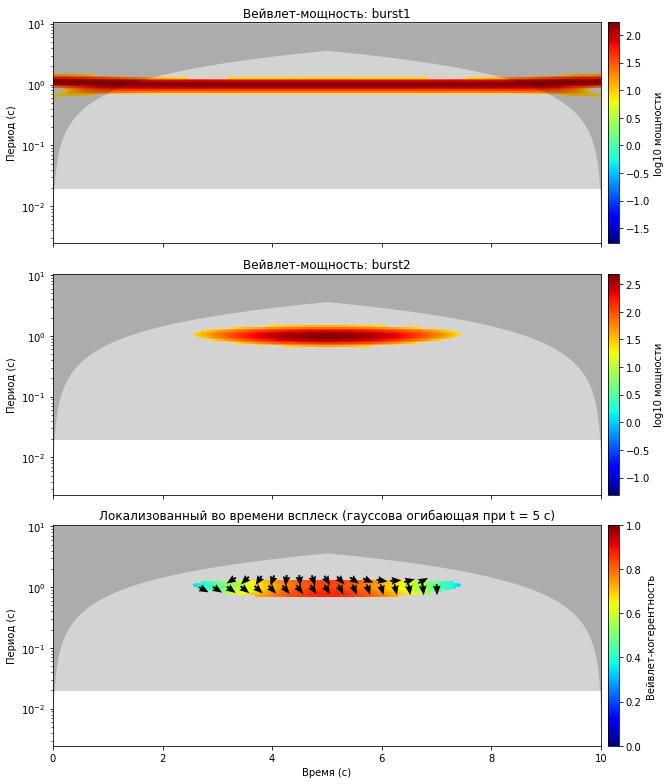

In [16]:
burst1 = np.sin(2 * np.pi * t)
envelope = np.exp(-((t - 5) ** 2) / (2 * 1.0 ** 2))
burst2 = np.sin(2 * np.pi * t + np.pi / 3) * envelope

plot_signals(t, burst1, burst2,
             "Локализованный во времени всплеск (гауссова огибающая при t = 5 с)",
             label1="burst1", label2="burst2")

plot_wct(t, burst1, burst2,
         "Локализованный во времени всплеск (гауссова огибающая при t = 5 с)",
         label1="burst1", label2="burst2")
plt.tight_layout()
plt.show()

### Влияние шума

Реальные измерения зашумлены. Здесь мы добавляем **независимый** белый
гауссов шум (стандартное отклонение 0.3) к каждому из двух сигналов и
повторяем анализ.

Добавлять шум к двум каналам нужно *независимо*: если бы к обоим добавили
**один и тот же** шум, он коррелировал бы идеально и создавал *ложную*
когерентность на всех масштабах. При независимом шуме локализованные
когерентные структуры сохраняются, потому что они находятся там, где
доминирует мощность сигнала, а шум лишь поднимает «пол» мощности на малых
периодах — именно те области, которые маска и так закрашивает серым.

In [17]:
def add_independent_noise(y1, y2, sigma=0.3, seed=0):
    # Добавляет независимый белый гауссов шум к каждому из двух сигналов.
    rng = np.random.default_rng(seed)
    n1 = rng.normal(0.0, sigma, y1.size)
    n2 = rng.normal(0.0, sigma, y2.size)
    return y1 + n1, y2 + n2

#### Смена режима с шумом

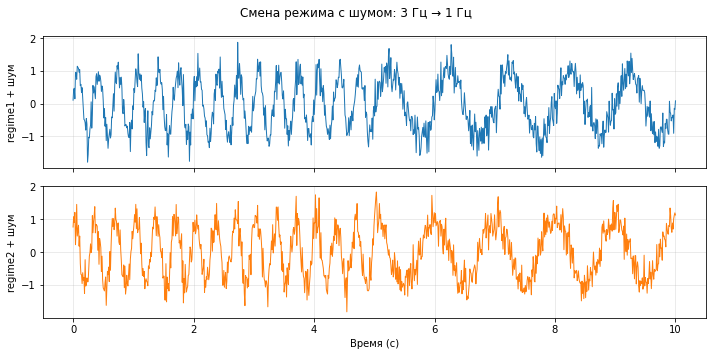

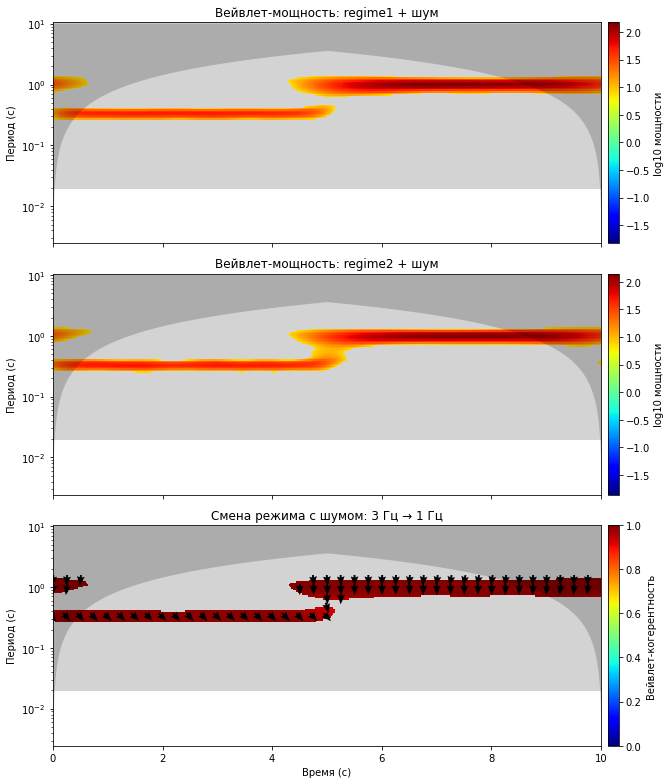

In [18]:
regime1_n, regime2_n = add_independent_noise(regime1, regime2, seed=1)

plot_signals(t, regime1_n, regime2_n, "Смена режима с шумом: 3 Гц → 1 Гц",
             label1="regime1 + шум", label2="regime2 + шум")

plot_wct(t, regime1_n, regime2_n, "Смена режима с шумом: 3 Гц → 1 Гц",
         label1="regime1 + шум", label2="regime2 + шум")
plt.tight_layout()
plt.show()

#### Тон и чирп с шумом

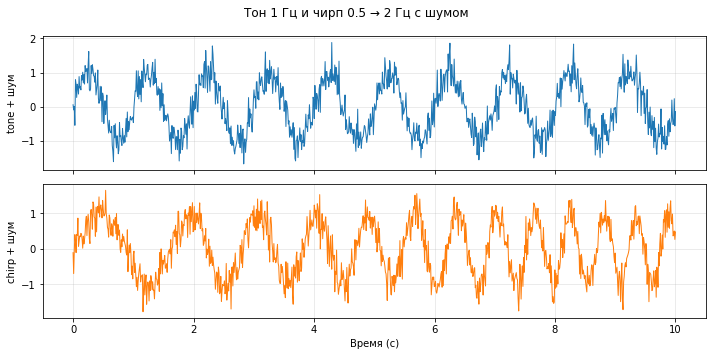

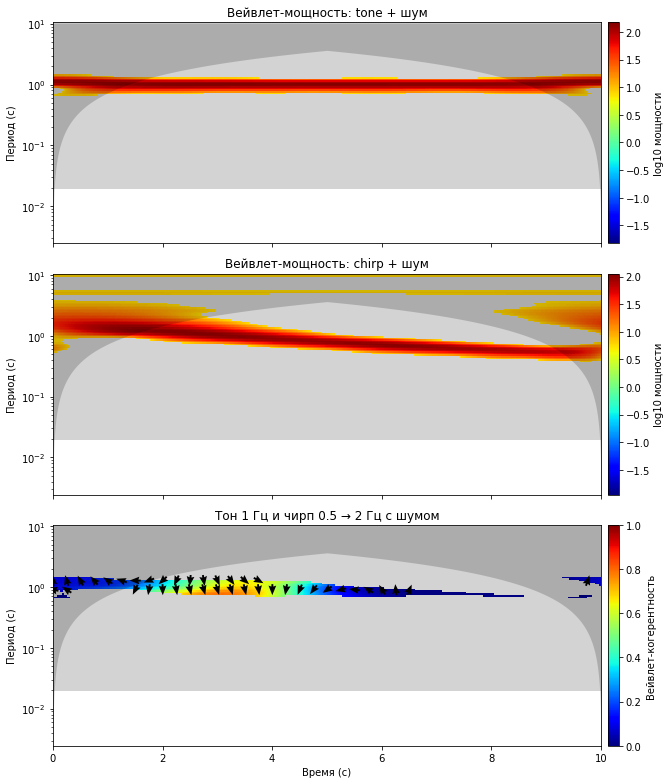

In [19]:
tone_n, chirp_n = add_independent_noise(tone, chirp, seed=2)

plot_signals(t, tone_n, chirp_n, "Тон 1 Гц и чирп 0.5 → 2 Гц с шумом",
             label1="tone + шум", label2="chirp + шум")

plot_wct(t, tone_n, chirp_n, "Тон 1 Гц и чирп 0.5 → 2 Гц с шумом",
         label1="tone + шум", label2="chirp + шум")
plt.tight_layout()
plt.show()

#### Скачок фазы с шумом

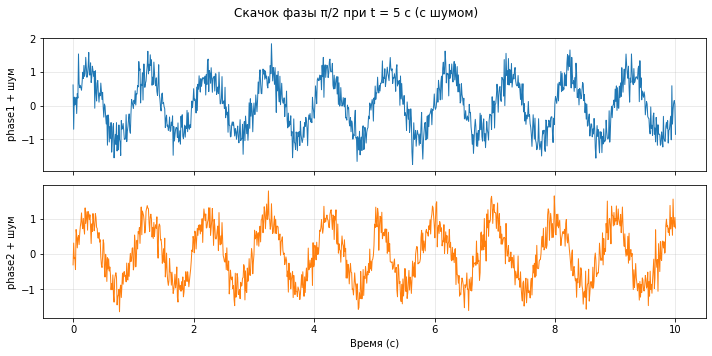

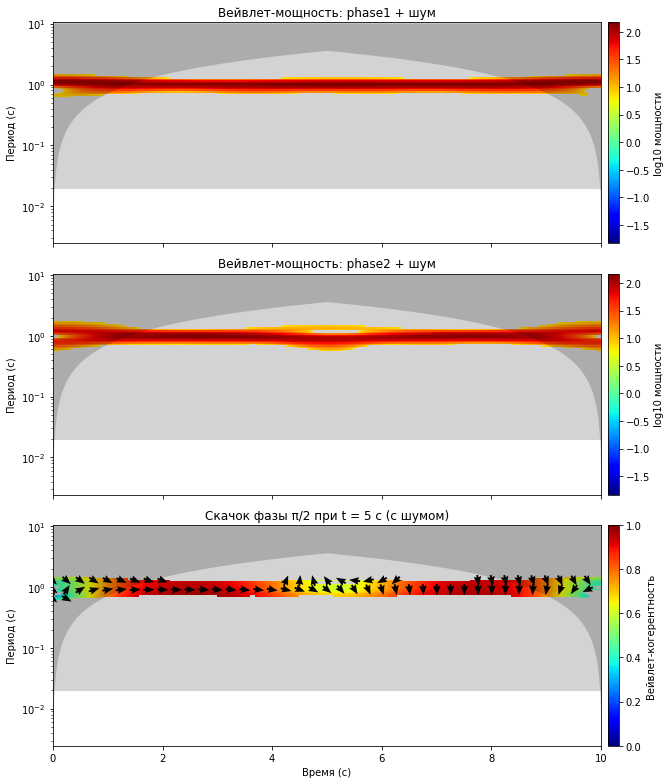

In [20]:
phase1_n, phase2_n = add_independent_noise(phase1, phase2, seed=3)

plot_signals(t, phase1_n, phase2_n, "Скачок фазы π/2 при t = 5 с (с шумом)",
             label1="phase1 + шум", label2="phase2 + шум")

plot_wct(t, phase1_n, phase2_n, "Скачок фазы π/2 при t = 5 с (с шумом)",
         label1="phase1 + шум", label2="phase2 + шум")
plt.tight_layout()
plt.show()

#### Всплеск с шумом

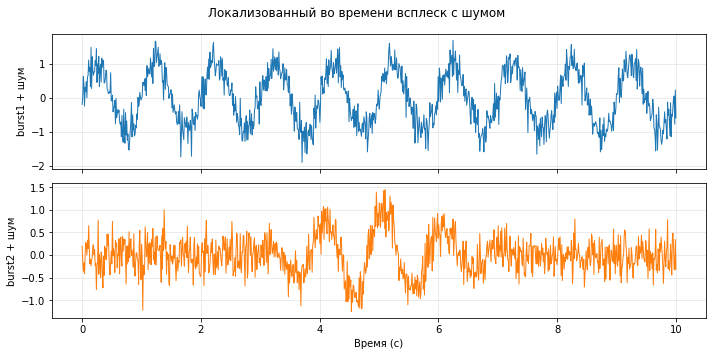

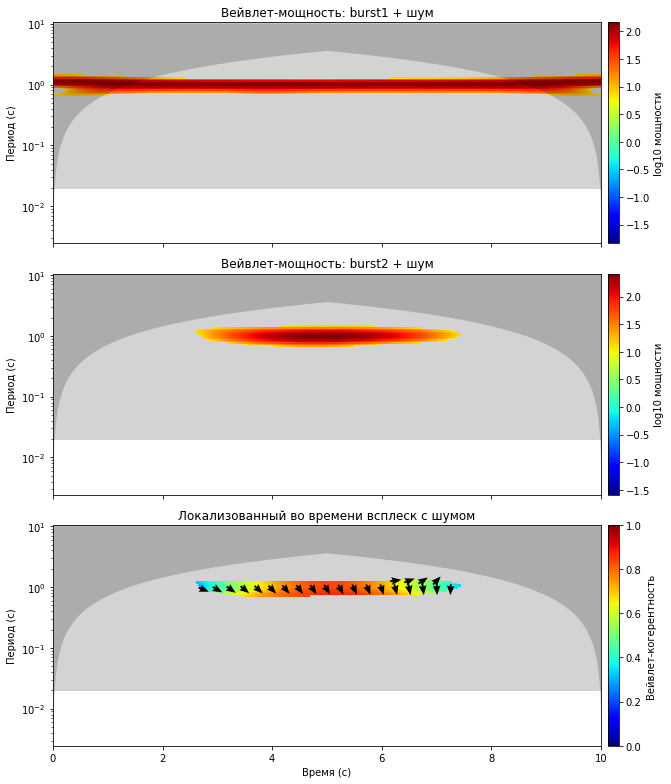

In [21]:
burst1_n, burst2_n = add_independent_noise(burst1, burst2, seed=4)

plot_signals(t, burst1_n, burst2_n, "Локализованный во времени всплеск с шумом",
             label1="burst1 + шум", label2="burst2 + шум")

plot_wct(t, burst1_n, burst2_n, "Локализованный во времени всплеск с шумом",
         label1="burst1 + шум", label2="burst2 + шум")
plt.tight_layout()
plt.show()

Вместе эти примеры показывают преимущество представления «время–частота»:
изменения частоты, изменения фазы и прерывистые зависимости **разрешаются во
времени**, а не размываются в одно среднее.

## Итоги

* Постоянный сдвиг фазы проявляется как устойчивое направление стрелок в
  когерентной полосе (вправо — в фазе, вниз — отставание 90°, влево — 180°).
* Амплитуда не влияет на когерентность — важна только форма/корреляция.
* Аддитивный шум разрушает когерентность на малых периодах (высоких частотах),
  тогда как доминирующий период остаётся видимым.
* Сначала читайте две панели мощности: они показывают, какие периоды реально
  присутствуют в каждом сигнале. Панель когерентности окрашивает только те
  масштабы, где у обоих сигналов есть значимая мощность.
* Нестационарные зависимости (смены режима, чирпы, скачки фазы, всплески)
  выглядят как **локализованные пятна или гребни** во времени, а не как
  однородные полосы.
* Вейвлет-когерентность — **нормированная** величина: она может быть большой
  там, где у обоих сигналов мощность пренебрежимо мала. Доверяйте только
  **незамаскированной** (окрашенной) области, где у обоих сигналов значимая
  мощность, и оставайтесь внутри конуса влияния (незакрашенная область).
* Для пары без общих частот (`sin1` и `sin10`) после маскирования
  когерентности практически не остаётся — прежний широкий цвет был
  артефактом.


## Вейвлет-разложение

До этого мы смотрели на вейвлет-мощность и когерентность. Теперь разберёмся, что
именно делает вейвлет-преобразование: как оно **раскладывает функцию** на
вейвлеты разных масштабов и положений и как из этих компонент сигнал собирается
обратно.

### Непрерывное вейвлет-разложение (CWT)

Непрерывное вейвлет-преобразование сопоставляет сигналу $x(t)$ коэффициенты
$W(a,b)$ на всех масштабах $a$ и положениях $b$:

$$W(a,b) = \frac{1}{\sqrt{a}}\int_{-\infty}^{\infty}
  x(t)\,\psi^*\!\left(\frac{t-b}{a}\right)\,dt,$$

где $\psi$ — материнский вейвлет. Мы используем вейвлет Морле

$$\psi(t) = \pi^{-1/4}\,e^{i\omega_0 t}\,e^{-t^2/2},$$

а масштаб $a$ связан с эквивалентной частотой $f \approx f_\lambda / a$.

Разложение — это набор компонент на разных масштабах. Обратное преобразование
(Торренс и Компо, 1998, формула 11) собирает сигнал обратно:

$$x(t) = \frac{\delta j\,\sqrt{\delta t}}{C_\delta\,\psi(0)}
  \sum_a \frac{\mathrm{Re}\,W(a,t)}{\sqrt{a}}.$$

Ниже: вейвлет Морле на нескольких масштабах, разложение чирпа и анимация, где
сигнал **пошагово собирается из масштабов**.

In [22]:
# Тестовый сигнал: линейный чирп (частота растёт со временем)
fs, T = 100.0, 8.0
n = int(fs * T)
t = np.arange(n) / fs
dt = 1.0 / fs
f0, f1 = 0.5, 3.0
chirp = np.sin(2 * np.pi * (f0 * t + (f1 - f0) / (2 * T) * t ** 2))

# Непрерывное вейвлет-преобразование
wavelet = Morlet()
lam = wavelet.flambda()
fmin, fmax = 0.2, 4.0
dj = 1 / 12
s0 = 1.0 / (fmax * lam)
J = int(round(np.log2(fmax / fmin) / dj))
W, sj, freqs, coi, _, _ = pycwt.cwt(chirp, dt, dj=dj, s0=s0, J=J, wavelet=wavelet)
print("форма W (масштабы x время):", W.shape,
      "| частоты: %.2f-%.2f Гц" % (freqs.min(), freqs.max()))

# Вклад каждого масштаба в восстановление (формула 11)
psi0 = complex(wavelet.psi(0)).real
comp = dj * np.sqrt(dt) / (wavelet.cdelta * psi0) * (np.real(W) / np.sqrt(sj[:, None]))

форма W (масштабы x время): (53, 800) | частоты: 0.20-4.00 Гц


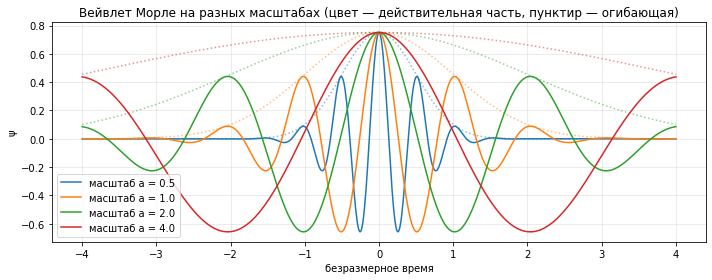

In [23]:
# Вейвлет Морле на разных масштабах: видно растяжение (дилатацию)
tt = np.linspace(-4, 4, 800)
fig, ax = plt.subplots(figsize=(10, 4))
for a, c in zip([0.5, 1.0, 2.0, 4.0], ["C0", "C1", "C2", "C3"]):
    psi = wavelet.psi(tt / a)
    ax.plot(tt, psi.real, color=c, label=f"масштаб a = {a}")
    ax.plot(tt, np.abs(psi), color=c, ls=":", alpha=0.5)
ax.set_xlabel("безразмерное время")
ax.set_ylabel("ψ")
ax.set_title("Вейвлет Морле на разных масштабах (цвет — действительная часть, пунктир — огибающая)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_127631/1970004050.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


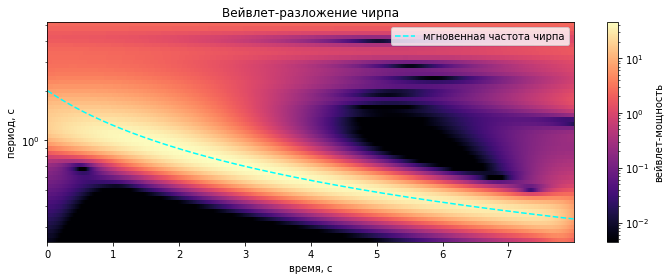

In [24]:
from matplotlib.colors import LogNorm

pow_chirp = np.abs(W) ** 2
fig, ax = plt.subplots(figsize=(10, 4))
mesh = ax.pcolormesh(t, 1 / freqs, pow_chirp, cmap="magma", shading="auto",
                     norm=LogNorm(vmin=pow_chirp.max() * 1e-4, vmax=pow_chirp.max()))
ax.plot(t, 1 / (f0 + (f1 - f0) * t / T), color="cyan", ls="--", lw=1.5,
        label="мгновенная частота чирпа")
ax.set_yscale("log")
ax.set_xlabel("время, с")
ax.set_ylabel("период, с")
ax.set_title("Вейвлет-разложение чирпа")
ax.legend()
fig.colorbar(mesh, ax=ax, label="вейвлет-мощность")
plt.tight_layout()
plt.show()

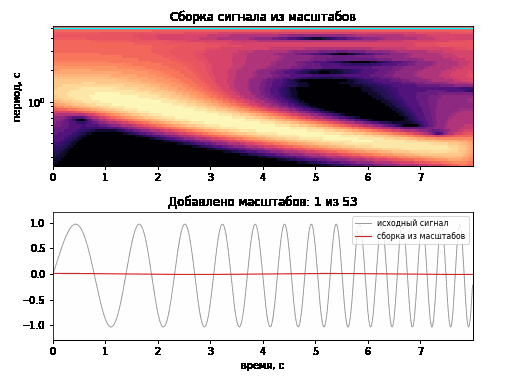

In [25]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# Порядок масштабов: от больших (низкие частоты) к малым (высокие)
order = np.argsort(sj)[::-1]
cum = np.cumsum(comp[order], axis=0)
target = chirp - chirp.mean()

n_frames = 60
frames_idx = np.linspace(0, len(order) - 1, n_frames).astype(int)

fig = plt.figure(figsize=(7.5, 5.4))
ax1 = fig.add_axes([0.10, 0.56, 0.80, 0.37])
ax2 = fig.add_axes([0.10, 0.10, 0.80, 0.34])

ax1.pcolormesh(t, 1 / freqs, pow_chirp, cmap="magma", shading="auto",
               norm=LogNorm(vmin=pow_chirp.max() * 1e-4, vmax=pow_chirp.max()))
ax1.set_yscale("log")
ax1.set_ylabel("период, с")
ax1.set_title("Сборка сигнала из масштабов")
hline = ax1.axhline(1 / freqs[order[0]], color="cyan", lw=1.5)

ax2.plot(t, target, color="0.6", lw=1, label="исходный сигнал")
line, = ax2.plot([], [], color="C3", lw=1.2, label="сборка из масштабов")
ax2.set_xlabel("время, с")
ax2.set_xlim(t[0], t[-1])
ax2.set_ylim(target.min() * 1.25, target.max() * 1.25)
ax2.legend(loc="upper right", fontsize=8)


def update(k):
    i = frames_idx[k]
    hline.set_ydata([1 / freqs[order[i]], 1 / freqs[order[i]]])
    line.set_data(t, cum[i])
    ax2.set_title(f"Добавлено масштабов: {i + 1} из {len(order)}")
    return hline, line


anim = FuncAnimation(fig, update, frames=n_frames, interval=100)
anim.save("anim_cwt_reconstruction.gif", writer=PillowWriter(fps=12), dpi=70)
plt.close(fig)
display(Image(filename="anim_cwt_reconstruction.gif"))

### Дискретное вейвлет-разложение (DWT)

Дискретное вейвлет-преобразование раскладывает сигнал по уровням: на каждом
уровне получаются **аппроксимирующие** (approximation, `cA`) и
**детализирующие** (detail, `cD`) коэффициенты. Это многомасштабный анализ
(MRA): грубая форма сигнала плюс детали всё более высокого разрешения.

В отличие от CWT, DWT использует фиксированную сетку уровней и ортогональные
вейвлеты, поэтому сигнал восстанавливается точно.

Итерации фильтр-банка (низкочастотный фильтр $h$ и высокочастотный $g$):

$$a_{j+1}[k] = \sum_n h[n-2k]\,a_j[n], \qquad
  d_{j+1}[k] = \sum_n g[n-2k]\,a_j[n],$$

$$a_j[n] = \sum_k h[n-2k]\,a_{j+1}[k] + \sum_k g[n-2k]\,d_{j+1}[k].$$

#### Отцовский и материнский вейвлеты

Ортогональный базис строят **отцовский** (масштабирующий) вейвлет $\phi$ и
**материнский** вейвлет $\psi$, связанные соотношениями двух масштабов:

$$\phi(x) = \sqrt{2}\sum_n h[n]\,\phi(2x-n), \qquad
  \psi(x) = \sqrt{2}\sum_n g[n]\,\phi(2x-n),$$

и их сдвинуто-растянутые версии

$$\phi_{j,k}(x) = 2^{j/2}\phi(2^{j}x-k), \qquad
  \psi_{j,k}(x) = 2^{j/2}\psi(2^{j}x-k).$$

#### Разложение функции в $L^2(\mathbb{R})$

Для любой функции $f \in L^2(\mathbb{R})$ отцовский и материнский вейвлеты
образуют ортонормированный базис, поэтому

$$f = \sum_{k}\langle f,\phi_{j_0,k}\rangle\,\phi_{j_0,k}
   + \sum_{j=j_0}^{\infty}\sum_{k}\langle f,\psi_{j,k}\rangle\,\psi_{j,k},$$

где $c_{j_0,k} = \langle f,\phi_{j_0,k}\rangle$ — **аппроксимирующие**
коэффициенты (грубая форма), а $d_{j,k} = \langle f,\psi_{j,k}\rangle$ —
**детализирующие** (детали каждого масштаба). Скалярное произведение
$\langle f,g\rangle = \int f(x)\,g(x)\,dx$.

Для ортогонального базиса выполняется **равенство Парсеваля** (сохранение
энергии):

$$\lVert f\rVert^2 = \sum_{k}\lvert c_{j_0,k}\rvert^2
   + \sum_{j=j_0}^{\infty}\sum_{k}\lvert d_{j,k}\rvert^2.$$

В дискретном случае конечной длины этому соответствуют функции `pywt.wavedec`
(разложение) и `pywt.waverec` (точное восстановление); ниже используется
вейвлет Добеши `db4`.

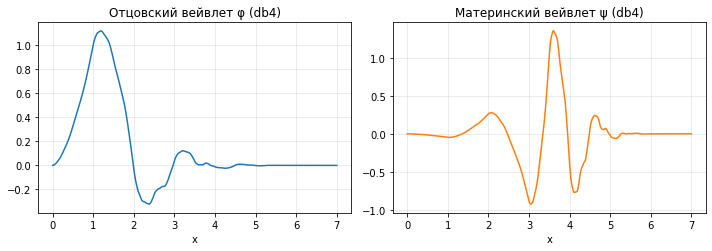

In [26]:
import pywt

# Отцовский (phi) и материнский (psi) вейвлеты db4
w = pywt.Wavelet("db4")
phi, psi, xw = w.wavefun(level=6)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
axs[0].plot(xw, phi, color="C0")
axs[0].set_title("Отцовский вейвлет φ (db4)")
axs[1].plot(xw, psi, color="C1")
axs[1].set_title("Материнский вейвлет ψ (db4)")
for ax in axs:
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

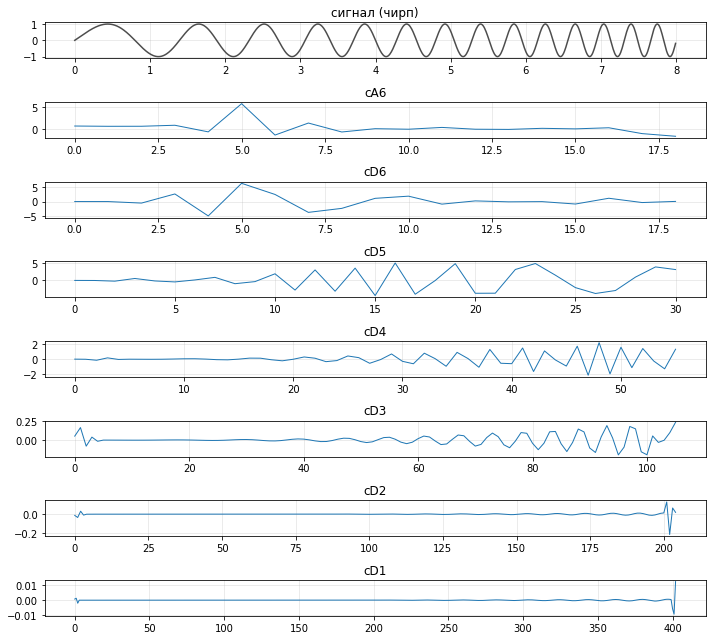

Относительная погрешность восстановления (DWT): 4.26e-16


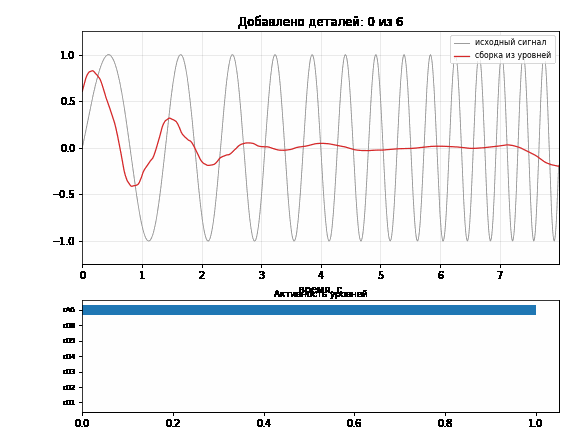

In [27]:
mra = pywt.wavedec(chirp, "db4", level=6, mode="symmetric")
names = ["cA6", "cD6", "cD5", "cD4", "cD3", "cD2", "cD1"]

fig, axs = plt.subplots(len(mra) + 1, 1, figsize=(10, 9))
axs[0].plot(t, chirp, color="0.3")
axs[0].set_title("сигнал (чирп)")
for ax, c, name in zip(axs[1:], mra, names):
    ax.plot(c, color="C0", lw=1)
    ax.set_title(name)
for ax in axs:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

rec = pywt.waverec(mra, "db4", mode="symmetric")[: len(chirp)]
err = np.linalg.norm(rec - chirp) / np.linalg.norm(chirp)
print("Относительная погрешность восстановления (DWT): %.2e" % err)

# --- GIF: постепенная сборка сигнала из уровней ---
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

sub = 5  # кадров на плавное добавление одного уровня
n_details = len(mra) - 1


def reconstruct(active):
    # active[i] in [0,1] — доля детали mra[i+1] (порядок cD6..cD1)
    coeffs = [mra[0]] + [active[i] * mra[i + 1] for i in range(n_details)]
    return pywt.waverec(coeffs, "db4", mode="symmetric")[: len(chirp)]


alphas = np.zeros(n_details)
frames = [alphas.copy()]
for i in range(n_details):
    for s in range(1, sub + 1):
        a = alphas.copy()
        a[i] = s / sub
        frames.append(a)
        if s == sub:
            alphas[i] = 1.0

fig = plt.figure(figsize=(8.4, 6.4))
ax1 = fig.add_axes([0.14, 0.41, 0.81, 0.52])
ax2 = fig.add_axes([0.14, 0.08, 0.81, 0.25])

ax1.plot(t, chirp, color="0.6", lw=1, label="исходный сигнал")
recon_line, = ax1.plot([], [], color="C3", lw=1.3, label="сборка из уровней")
ax1.set_xlim(t[0], t[-1])
ax1.set_ylim(chirp.min() * 1.25, chirp.max() * 1.25)
ax1.set_xlabel("время, с")
ax1.legend(loc="upper right", fontsize=8)
ax1.grid(alpha=0.3)

bar_names = ["cA6"] + names[1:]
bars = ax2.barh(range(len(bar_names)), np.zeros(len(bar_names)),
                color="C0", height=0.6)
ax2.set_yticks(range(len(bar_names)))
ax2.set_yticklabels(bar_names, fontsize=7)
ax2.set_xlim(0, 1.05)
ax2.invert_yaxis()
ax2.set_title("Активность уровней", fontsize=9, pad=3)


def update(k):
    active = frames[k]
    recon_line.set_data(t, reconstruct(active))
    for bar, v in zip(bars, [1.0] + list(active)):
        bar.set_width(v)
    ax1.set_title("Добавлено деталей: %d из %d"
                  % (int(round(active.sum())), n_details))
    return [recon_line] + list(bars)


anim = FuncAnimation(fig, update, frames=len(frames), interval=120)
anim.save("anim_dwt_reconstruction.gif", writer=PillowWriter(fps=10), dpi=70)
plt.close(fig)
display(Image(filename="anim_dwt_reconstruction.gif"))

### Вывод

* Вейвлет-преобразование раскладывает функцию на компоненты, локализованные и по
  времени, и по масштабу (частоте).
* Непрерывное разложение (CWT) даёт избыточное, но наглядное представление; из
  его масштабов сигнал собирается обратно (анимация выше).
* Дискретное разложение (DWT) даёт компактный набор уровней «аппроксимация +
  детали», из которых сигнал восстанавливается точно.
* Именно эта локализация по времени и масштабу лежит в основе вейвлет-мощности и
  вейвлет-когерентности, которые мы рассматривали выше.
* Отцовский $\phi$ и материнский $\psi$ вейвлеты образуют ортонормированный базис,
  по которому функция раскладывается в $L^2$ (аппроксимация + детали).

## References

* C. Torrence and G. P. Compo, "A Practical Guide to Wavelet Analysis",
  *Bulletin of the American Meteorological Society*, 79(1), 61–78, 1998.
* C. Torrence and P. J. Webster, "Interdecadal Changes in the ENSO–Monsoon
  System", *Journal of Climate*, 12(8), 2679–2690, 1999.
* A. Grinsted, J. C. Moore, and S. J. Jevrejeva, "Application of the cross
  wavelet transform and wavelet coherence to geophysical time series",
  *Nonlinear Processes in Geophysics*, 11, 561–566, 2004.
* `pycwt` documentation: <https://github.com/regeirk/pycwt>